In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import re
import copy
import random
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from cuml.manifold import TSNE, UMAP

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset

import sys
sys.path.append("/mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/Extras/LPD")
from lpd_resnet18 import LPDResNet18

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [4]:
with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "rb") as f:
    gmm_cache = pickle.load(f)

In [5]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

SSR_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [6]:
train_ds = filter_by_elev(SSR_synth_ds, {14, 15, 16})
valid_ds = filter_by_elev(meas_ds, {14, 15, 16})
test_ds = filter_by_elev(meas_ds, {17})

ds_dict = {"train" : train_ds, "val": valid_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "val": len(valid_ds), "test": len(test_ds)}

In [7]:
model_check = LPDResNet18(num_classes=10, logits_channels={"maxpool": 4, "layer2": 8, "layer3": 16, "layer4": 32})
pool_param_count = sum(p.numel() for n, p in model_check.named_parameters() if "component_selection" in n)
total_param_count = sum(p.numel() for p in model_check.parameters())
print(f"{pool_param_count} ({100*pool_param_count/total_param_count:.2f}% of total)")

210656 (1.85% of total)


In [8]:
# seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
seed_lst = [10, 42, 100, 123, 666]
 
train_loss = []
val_loss = []
train_acc = []
val_acc = []
 
for i, seed in enumerate(seed_lst):
    
    start = time.perf_counter()
    
    print(f"Training Run {i}: seed {seed}")
    set_seed(seed)
 
    dataloaders = {
        "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
 
    # --- CHANGED: LPD-ResNet18 instead of models.resnet18 ---
    # Dropout head is already built into LPDResNet18 (dropout_p=0.4 default),
    # so no separate model.fc = nn.Sequential(...) override needed here.
    model = LPDResNet18(num_classes=len(train_ds.class_to_idx), logits_channels={"maxpool": 4, "layer2": 8, "layer3": 16, "layer4": 32})
 
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss()
 
    # --- CHANGED: split params so LPD's internal phase-selection logits
    # (component_selection submodules) get weight_decay=0, everything
    # else (backbone convs/BN/fc) keeps your usual 2e-4. See paper
    # Appendix A4.4.1 for why: weight decay on the selection logits
    # pushes them toward equal magnitude, which destabilizes the hard
    # phase selection the shift-invariance guarantee depends on.
    net_pars, pool_pars = [], []
    for n, p in model.named_parameters():
        if "component_selection" in n and p.requires_grad:
            pool_pars.append(p)
        elif p.requires_grad:
            net_pars.append(p)
 
    optimizer = optim.AdamW([
        {"params": net_pars, "weight_decay": 2e-4},
        {"params": pool_pars, "weight_decay": 0},
    ], lr=3e-4)
 
    scheduler = CosineAnnealingLR(optimizer, T_max=200, eta_min=3e-7)
 
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
 
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }
 
    # Training loop
    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            # --- CHANGED: conv1 now lives under model.core.conv1,
            # since LPDResNet18 wraps a torchvision ResNet as self.core
            print(f"First layer mean: {model.core.conv1.weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
 
            running_loss = 0.0
            running_corrects = 0
 
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
 
                optimizer.zero_grad()
 
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
 
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
 
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
 
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
 
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
 
            print(f"{phase} Loss: {epoch_loss:.7f} Acc: {epoch_acc:.7f}")
 
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")
 
    print("Training complete!")
 
    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    val_acc.append(history["val_acc"])
 
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Extras/LPD/SSR_w_noise/rn18_seed{seed}_b16_logits_4_8_16_32.pth"))
    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")
 
train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
val_acc = np.array(val_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: 0.000035
train Loss: 2.3559670 Acc: 0.1662531
val Loss: 2.2968549 Acc: 0.1315136
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 2.1534881 Acc: 0.2059553
val Loss: 2.3210760 Acc: 0.1364764
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 2.1091215 Acc: 0.2133995
val Loss: 2.4000236 Acc: 0.1116625
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 2.0626981 Acc: 0.2468983
val Loss: 2.2258121 Acc: 0.1662531
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 1.9402464 Acc: 0.2791563
val Loss: 2.4784288 Acc: 0.1588089
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 1.9439075 Acc: 0.2493797
val Loss: 2.1939572 Acc: 0.1811414
Epoch 5 LR: 0.0002993350
Epoch 6
train Loss: 1.8206873 Acc: 0.2928040
val Loss: 2.5485906 Acc: 0.0955335
Epoch 6 LR: 0.0002990950
Epoch 7
train Loss: 1.7778681 Acc: 0.3250620
val Loss: 2.2780919 Acc: 0.2642680
Epoch 7 LR: 0.0002988184
Epoch 8
train Loss: 1.6948637 Acc: 0.3300248
val Loss: 2.3353272 Acc: 0.1426799
Epoch 8 LR: 0.0002985050
Epoc

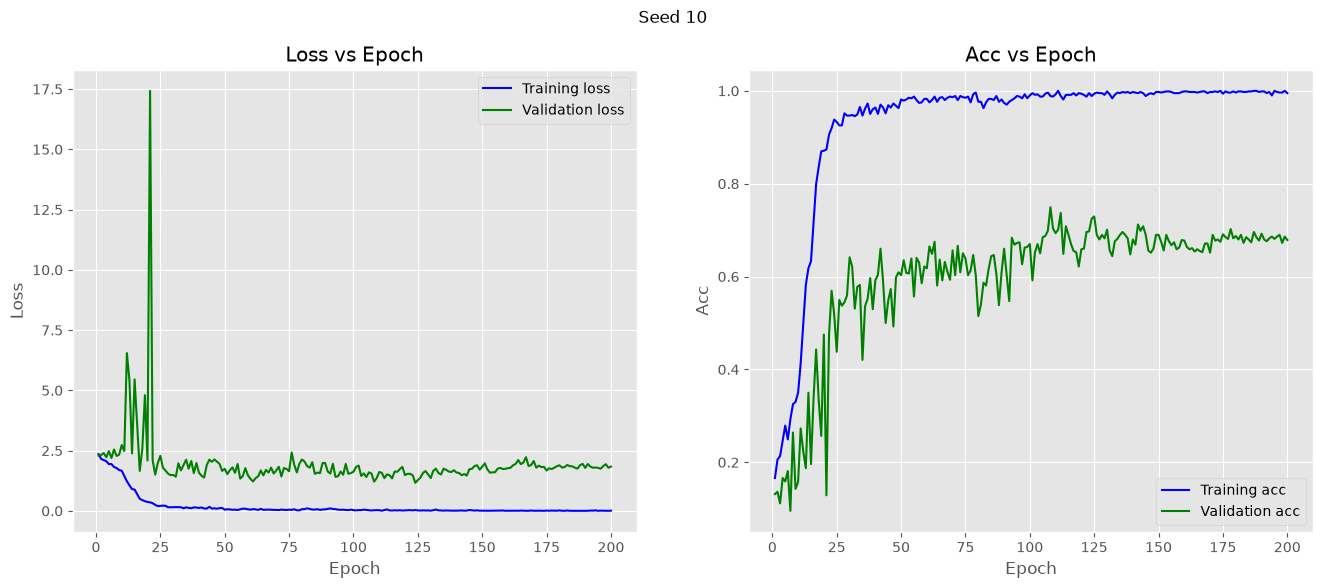

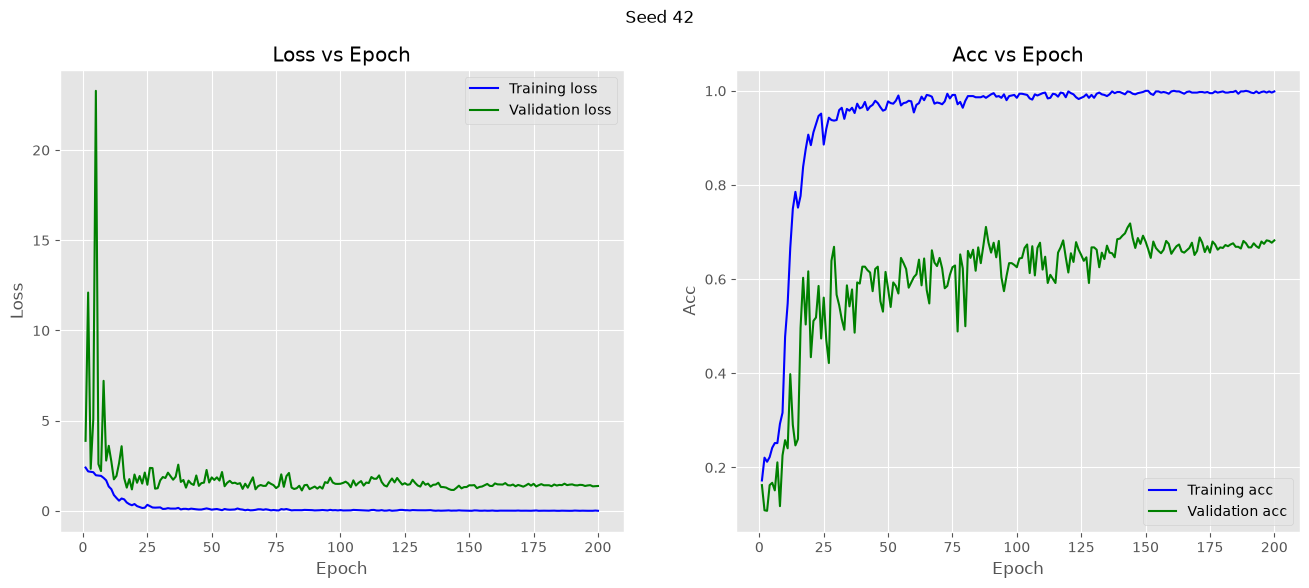

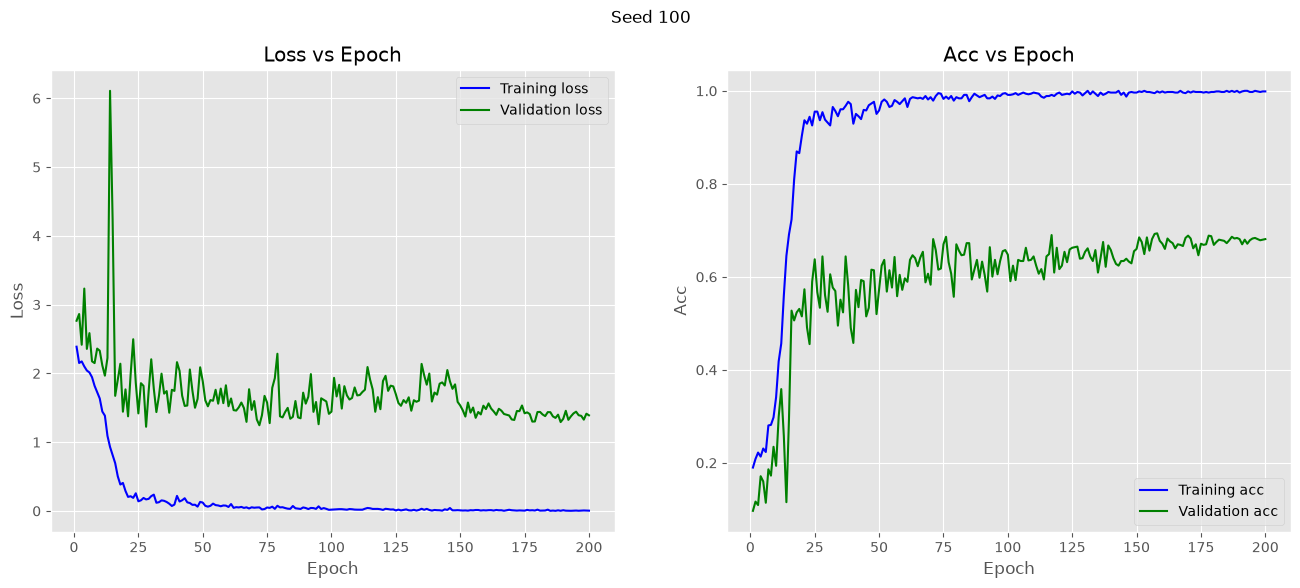

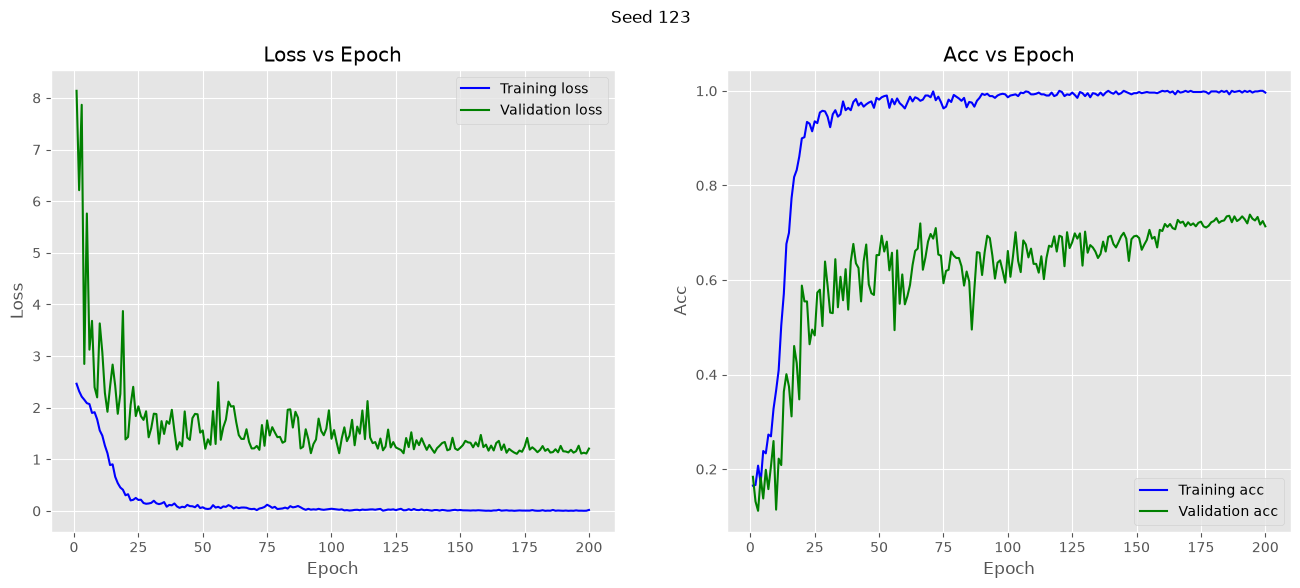

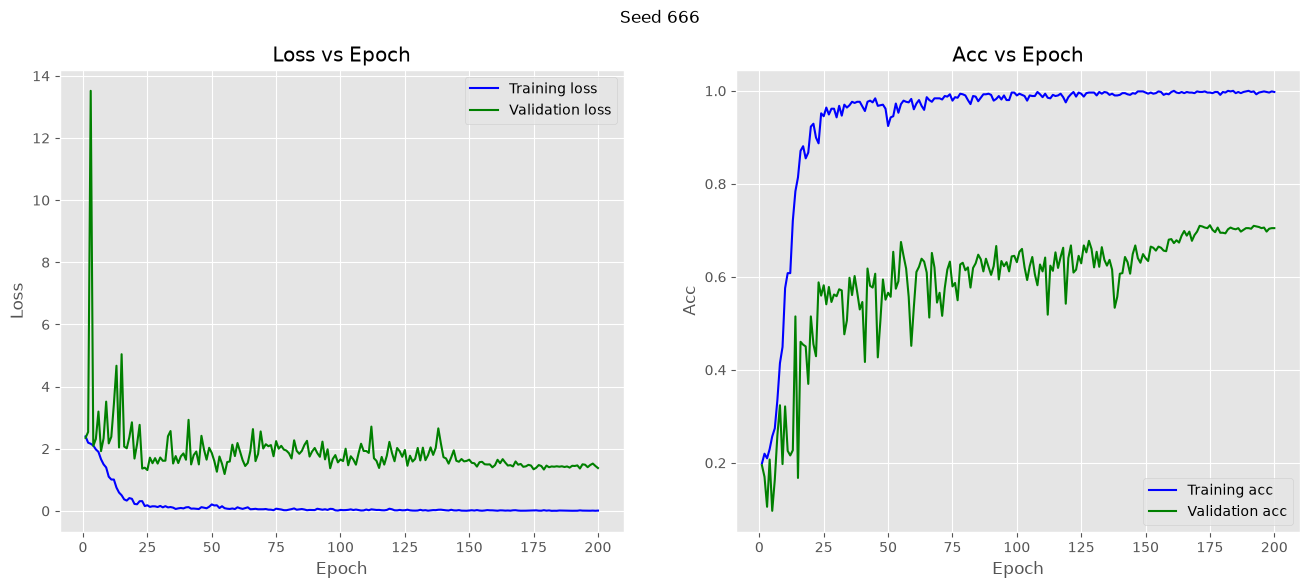

In [9]:
row, col = train_loss.shape

for i, seed in enumerate(seed_lst):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (16, 6))
    
        ax0 = fig.add_subplot(1, 2, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 2, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_acc[i, :], label = "Training acc", c = "blue")
        ax1.plot(np.arange(1, num_epochs+1), val_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Acc")
        ax1.legend()
        ax1.grid(True)

        fig.suptitle(f"Seed {seed}")
        plt.show()

In [10]:
frozen = [n for n, p in model.named_parameters() if not p.requires_grad]
print(frozen)  # should print an empty list []

[]


In [11]:
[n for n, p in model.named_parameters() if "get_logits" in n]

['core.maxpool.0.component_selection.get_logits.conv1.weight',
 'core.maxpool.0.component_selection.get_logits.conv1.bias',
 'core.maxpool.0.component_selection.get_logits.conv2.weight',
 'core.maxpool.0.component_selection.get_logits.conv2.bias',
 'core.maxpool.3.component_selection.get_logits.conv1.weight',
 'core.maxpool.3.component_selection.get_logits.conv1.bias',
 'core.maxpool.3.component_selection.get_logits.conv2.weight',
 'core.maxpool.3.component_selection.get_logits.conv2.bias',
 'core.layer2.0.conv2.0.component_selection.get_logits.conv1.weight',
 'core.layer2.0.conv2.0.component_selection.get_logits.conv1.bias',
 'core.layer2.0.conv2.0.component_selection.get_logits.conv2.weight',
 'core.layer2.0.conv2.0.component_selection.get_logits.conv2.bias',
 'core.layer3.0.conv2.0.component_selection.get_logits.conv1.weight',
 'core.layer3.0.conv2.0.component_selection.get_logits.conv1.bias',
 'core.layer3.0.conv2.0.component_selection.get_logits.conv2.weight',
 'core.layer3.0.conv

In [9]:
seed_lst = [10, 42, 100, 123, 666]

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    new_model = LPDResNet18(num_classes=len(train_ds.class_to_idx), logits_channels={"maxpool": 4, "layer2": 8, "layer3": 16, "layer4": 32}) # dont load ImageNet Weights
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/LPD/SSR_w_noise/rn18_seed{seed}_b16_logits_4_8_16_32.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {100* test_acc:.4f}")
    test_acc_lst.append(test_acc)

test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Evaluating Run 0: Seed 10
Test Accuracy: 74.3970
Evaluating Run 1: Seed 42
Test Accuracy: 76.9944
Evaluating Run 2: Seed 100
Test Accuracy: 76.6234
Evaluating Run 3: Seed 123
Test Accuracy: 81.0761
Evaluating Run 4: Seed 666
Test Accuracy: 78.6642
Min: 74.3970
Max: 81.0761
Avg, Std: 77.5510, 2.2263


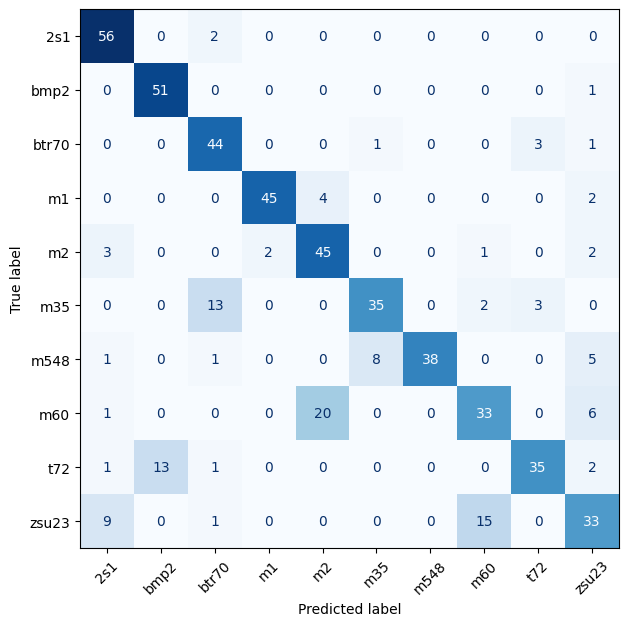

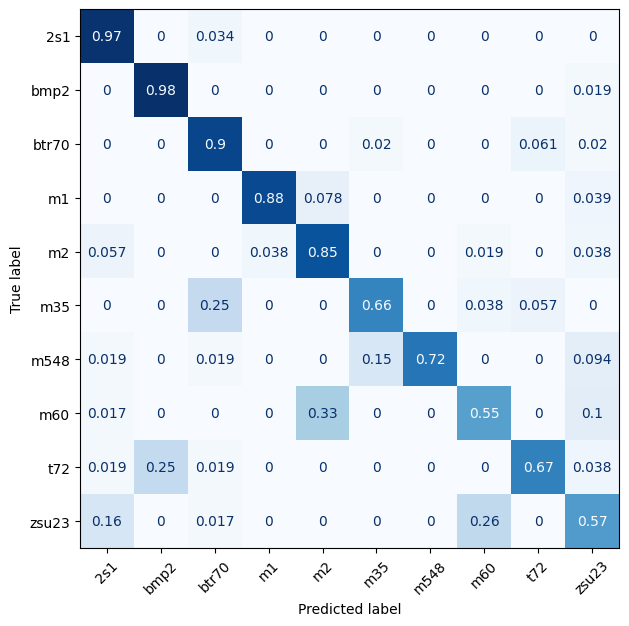

In [11]:
test_dataloader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

seed = 42
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

new_model = LPDResNet18(num_classes=len(train_ds.class_to_idx), logits_channels={"maxpool": 4, "layer2": 8, "layer3": 16, "layer4": 32}) # dont load ImageNet Weights

# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/LPD/SSR_w_noise/rn18_seed{seed}_b16_logits_4_8_16_32.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

n_test = len(test_ds)
labels_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
preds_tensor = torch.zeros(n_test, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        bs = inputs.size(0)
        labels_tensor[idx:idx+bs] = labels
        preds_tensor[idx:idx+bs] = preds
        idx += bs

_labels_all = labels_tensor.cpu().numpy()
_preds_all = preds_tensor.cpu().numpy()

cm = confusion_matrix(_labels_all, _preds_all)
cm_cpu = cp.asnumpy(cm)
disp = ConfusionMatrixDisplay(cm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.tick_params(axis='x', rotation=45)
plt.show()

cm_norm = confusion_matrix(_labels_all, _preds_all, normalize='true')
cm_norm_cpu = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.tick_params(axis='x', rotation=45)
plt.show()

In [12]:
shifted_left_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = -5, axis = -1), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
shifted_right_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = 15, axis = -1), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
shifted_up_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = 10, axis = -2), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
shifted_down_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = -10, axis = -2), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

shifted_left_17 = filter_by_elev(shifted_left_meas_ds, {17})
shifted_right_17 = filter_by_elev(shifted_right_meas_ds, {17})
shifted_up_17 = filter_by_elev(shifted_up_meas_ds, {17})
shifted_down_17 = filter_by_elev(shifted_down_meas_ds, {17})

In [14]:
seed_lst = [10, 42, 100, 123, 666]

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for ds in [shifted_left_17, shifted_right_17, shifted_up_17, shifted_down_17]:

    if ds is shifted_left_17:
        print("shifted left by 5 units")
    elif ds is shifted_right_17:
        print("shifted right by 15 units")
    elif ds is shifted_up_17:
        print("shifted up by 10 units")
    elif ds is shifted_down_17:
        print("shifted down by 10 units")
    
    for i, seed in enumerate(seed_lst):
        print(f"Evaluating Run {i}: Seed {seed}")
        new_model = LPDResNet18(num_classes=len(train_ds.class_to_idx), logits_channels={"maxpool": 4, "layer2": 8, "layer3": 16, "layer4": 32}) # dont load ImageNet Weights
        
        # Load your trained weights
        new_model.load_state_dict(torch.load(
            os.path.join(workspace, f"weights/SSR/Extras/LPD/SSR_w_noise/rn18_seed{seed}_b16_logits_4_8_16_32.pth"),
            map_location=device
        ))
        
        new_model = new_model.to(device)
        new_model.eval()
        
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in DataLoader(ds, batch_size=32, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
                inputs = inputs.to(device)
                labels = labels.to(device)
        
                outputs = new_model(inputs)
                _, preds = torch.max(outputs, 1)
        
                correct += torch.sum(preds == labels).item()
                total += labels.size(0)
        
        test_acc = correct / total
        print(f"Test Accuracy: {100 * test_acc:.4f}")
        test_acc_lst.append(test_acc)
    print("\n")

shifted left by 5 units
Evaluating Run 0: Seed 10
Test Accuracy: 74.3970
Evaluating Run 1: Seed 42
Test Accuracy: 76.9944
Evaluating Run 2: Seed 100
Test Accuracy: 76.6234
Evaluating Run 3: Seed 123
Test Accuracy: 81.0761
Evaluating Run 4: Seed 666
Test Accuracy: 78.6642


shifted right by 15 units
Evaluating Run 0: Seed 10
Test Accuracy: 74.3970
Evaluating Run 1: Seed 42
Test Accuracy: 76.9944
Evaluating Run 2: Seed 100
Test Accuracy: 76.6234
Evaluating Run 3: Seed 123
Test Accuracy: 81.0761
Evaluating Run 4: Seed 666
Test Accuracy: 78.6642


shifted up by 10 units
Evaluating Run 0: Seed 10
Test Accuracy: 74.3970
Evaluating Run 1: Seed 42
Test Accuracy: 76.9944
Evaluating Run 2: Seed 100
Test Accuracy: 76.6234
Evaluating Run 3: Seed 123
Test Accuracy: 81.0761
Evaluating Run 4: Seed 666
Test Accuracy: 78.6642


shifted down by 10 units
Evaluating Run 0: Seed 10
Test Accuracy: 74.3970
Evaluating Run 1: Seed 42
Test Accuracy: 76.9944
Evaluating Run 2: Seed 100
Test Accuracy: 76.6234
Eval

shifted left by 5 units


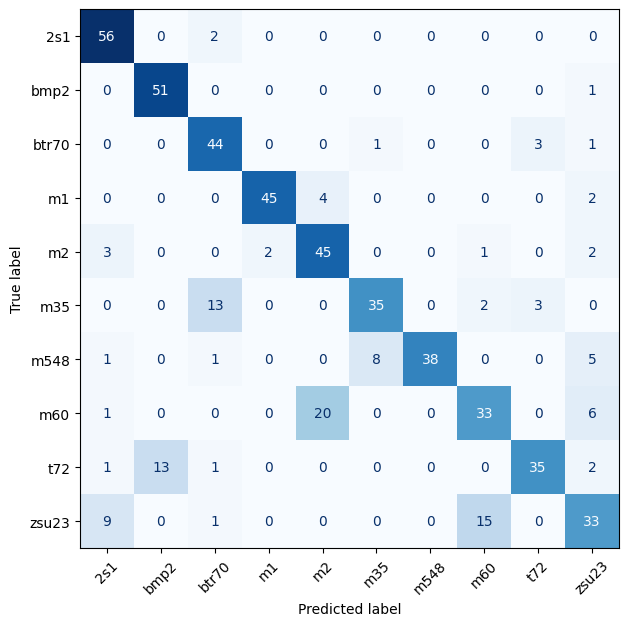

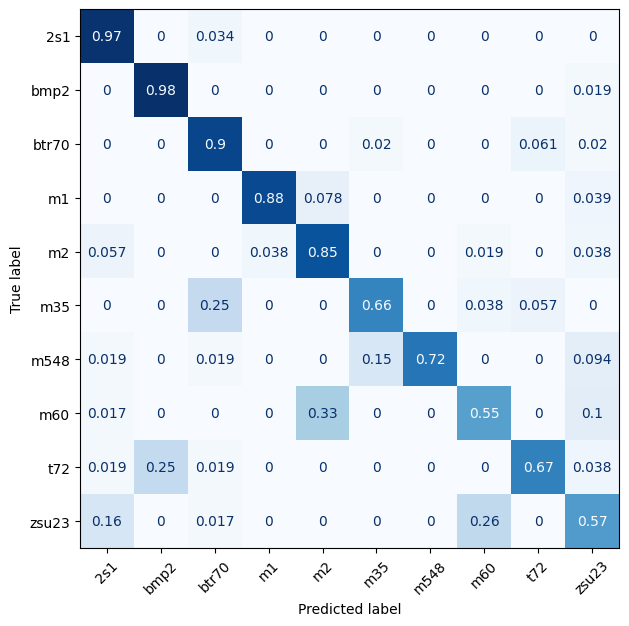

shifted right by 15 units


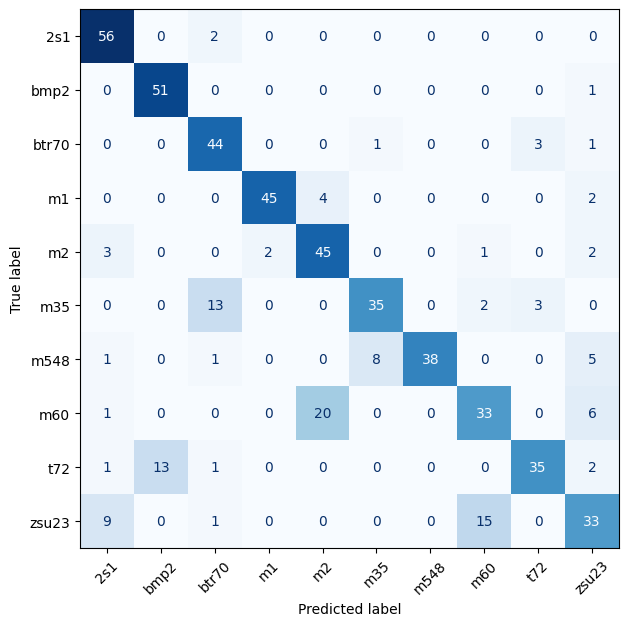

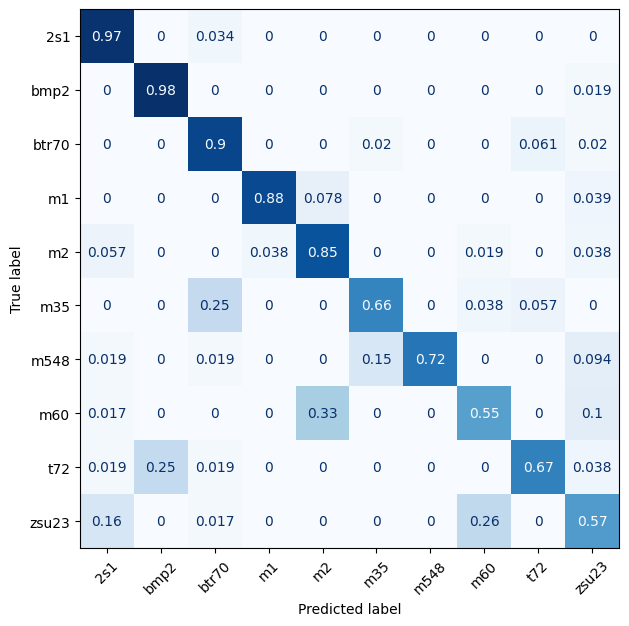

shifted up by 10 units


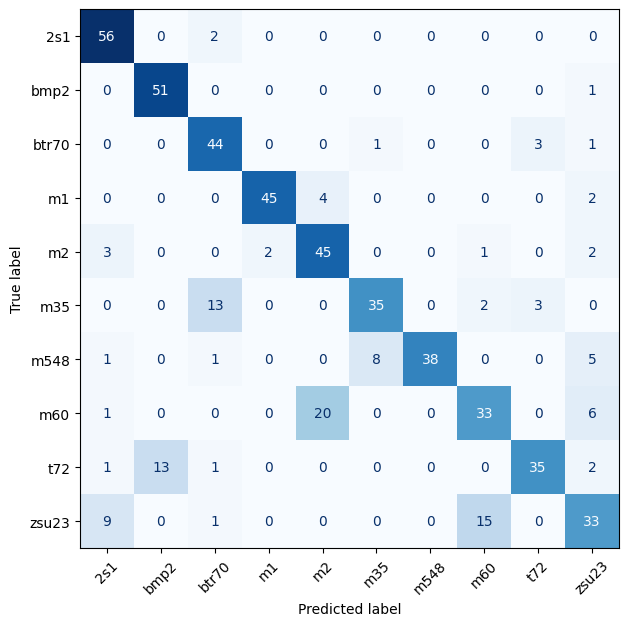

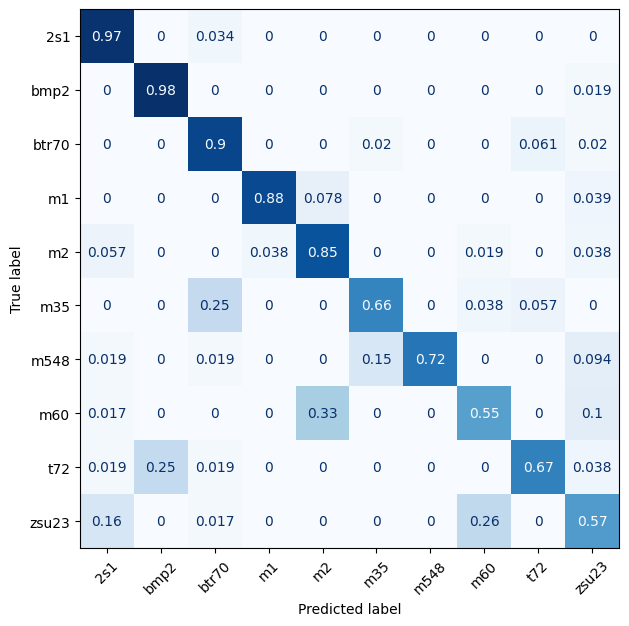

shifted down by 10 units


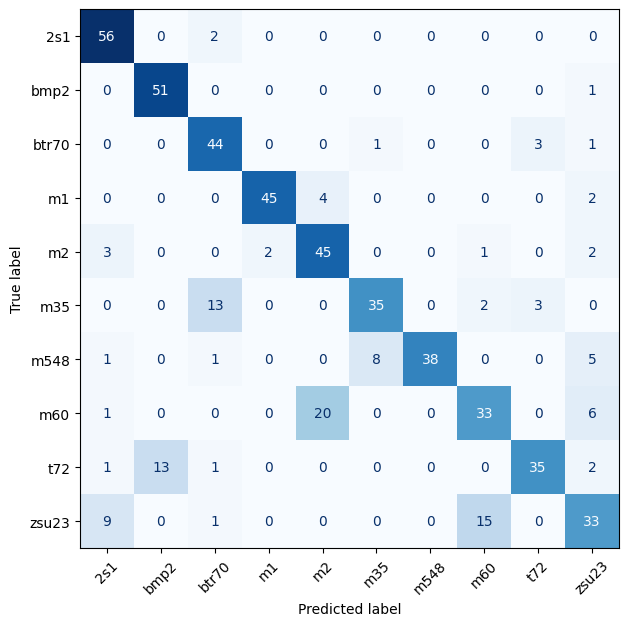

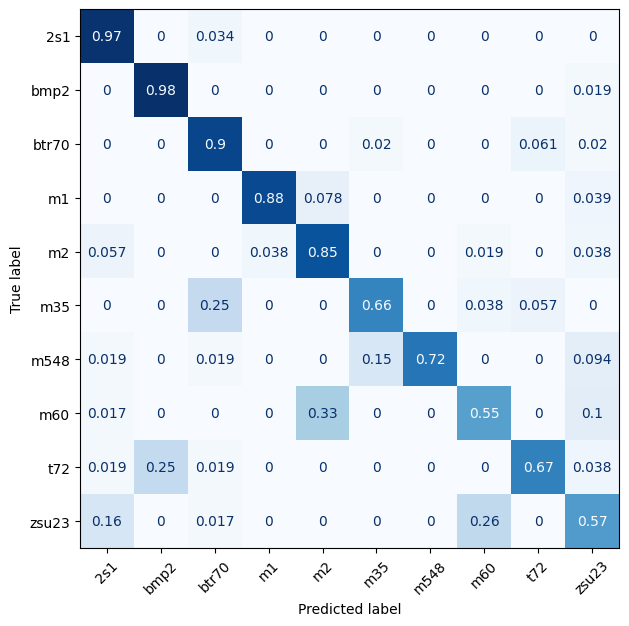

In [15]:
for ds in [shifted_left_17, shifted_right_17, shifted_up_17, shifted_down_17]:

    test_dataloader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

    if ds is shifted_left_17:
        print("shifted left by 5 units")
    elif ds is shifted_right_17:
        print("shifted right by 15 units")
    elif ds is shifted_up_17:
        print("shifted up by 10 units")
    elif ds is shifted_down_17:
        print("shifted down by 10 units")

    seed = 42
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    new_model = LPDResNet18(num_classes=len(train_ds.class_to_idx), logits_channels={"maxpool": 4, "layer2": 8, "layer3": 16, "layer4": 32}) # dont load ImageNet Weights
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/LPD/SSR_w_noise/rn18_seed{seed}_b16_logits_4_8_16_32.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()
    
    n_test = len(test_ds)
    labels_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
    preds_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
    
    idx = 0
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            bs = inputs.size(0)
            labels_tensor[idx:idx+bs] = labels
            preds_tensor[idx:idx+bs] = preds
            idx += bs
    
    _labels_all = labels_tensor.cpu().numpy()
    _preds_all = preds_tensor.cpu().numpy()
    
    cm = confusion_matrix(_labels_all, _preds_all)
    cm_cpu = cp.asnumpy(cm)
    disp = ConfusionMatrixDisplay(cm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.tick_params(axis='x', rotation=45)
    plt.show()
    
    cm_norm = confusion_matrix(_labels_all, _preds_all, normalize='true')
    cm_norm_cpu = cp.asnumpy(cm_norm)
    disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.tick_params(axis='x', rotation=45)
    plt.show()